In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla Deliveries Analysis — End-to-End ML Pipeline

**Dataset:** Tesla EA Deliveries and Production Data(2015 to 2025)
  
**Objective:** Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA,
feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

**Workflow of ML pipeline:**
1. Load Dataseta
2. Understand Dataset
3. Clean Data
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train-Test Split
7. Train Multiple Models
8. Evaluate Models
9. Hyperparameter Tuning
10. Compare Results
11. Time Series Forecasting
12. Final Conclusions

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [4]:
print(f"Dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
df.head()

Dataset shape: (2640, 12)
Total rows: 2640, Total columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Understand the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
# Check for missing values

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing values: 0


In [8]:
# Check unique values for categorical columns

cat_cols = ['Region', 'Model', 'Source_Type']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print(f"  Count: {df[col].nunique()}\n")

Region: ['Europe' 'Asia' 'North America' 'Middle East']
  Count: 4

Model: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
  Count: 5

Source_Type: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']
  Count: 3



## 4. Data Cleaning

In [9]:
# Remove duplicates (if any)

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (2640, 12)


In [10]:
# Check for duplicate rows

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [11]:
# Strip any extra whitespace from string columns (just in case)

for col in cat_cols:
    df[col] = df[col].str.strip()

print("Data cleaning done!")
print(f"Final clean dataset shape: {df.shape}")

Data cleaning done!
Final clean dataset shape: (2640, 12)


## 5. Exploratory Data Analysis (EDA)
- **Exploratory Data Analysis (EDA)**: The process of visualizing and summarizing the dataset to understand trends, spot anomalies, and find correlations between variables before modeling.

Let's visualize the data to understand patterns and relationships.

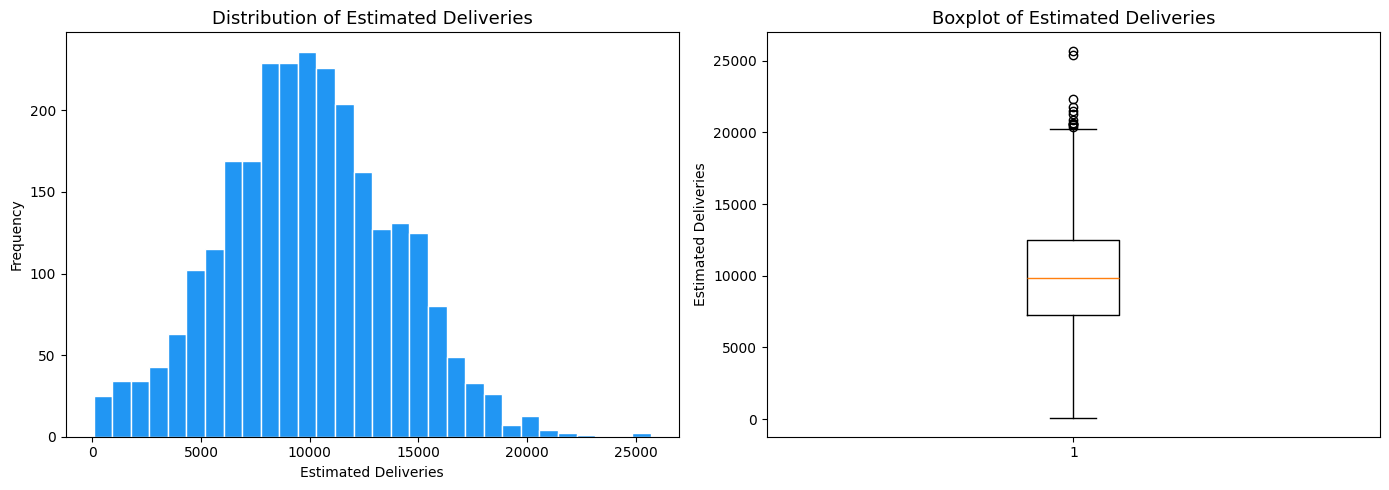

In [12]:
# Distribution of target variable — Estimated Deliveries

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Estimated_Deliveries'], bins=30, color='#2196F3', edgecolor='white')
axes[0].set_title('Distribution of Estimated Deliveries', fontsize=13)
axes[0].set_xlabel('Estimated Deliveries')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Estimated_Deliveries'], vert=True)
axes[1].set_title('Boxplot of Estimated Deliveries', fontsize=13)
axes[1].set_ylabel('Estimated Deliveries')

plt.tight_layout()
plt.show()

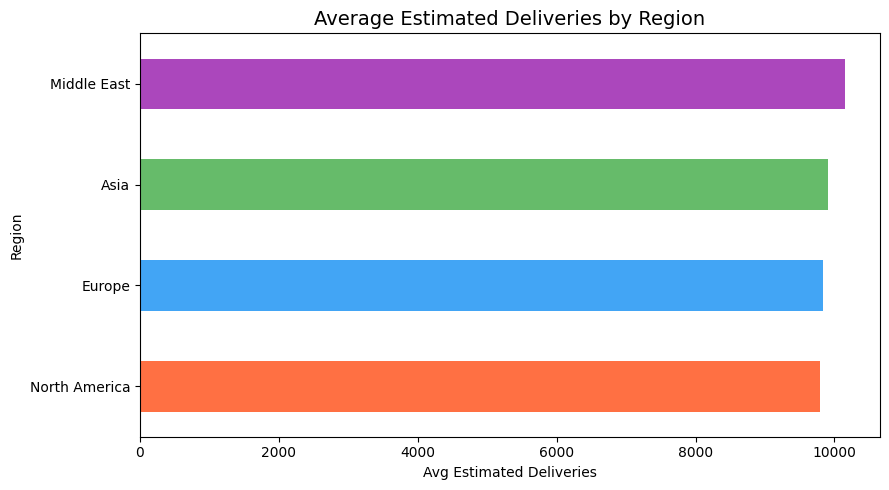

In [13]:
# Average deliveries by Region

region_avg = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
region_avg.plot(kind='barh', color=['#FF7043', '#42A5F5', '#66BB6A', '#AB47BC'])
plt.title('Average Estimated Deliveries by Region', fontsize=14)
plt.xlabel('Avg Estimated Deliveries')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

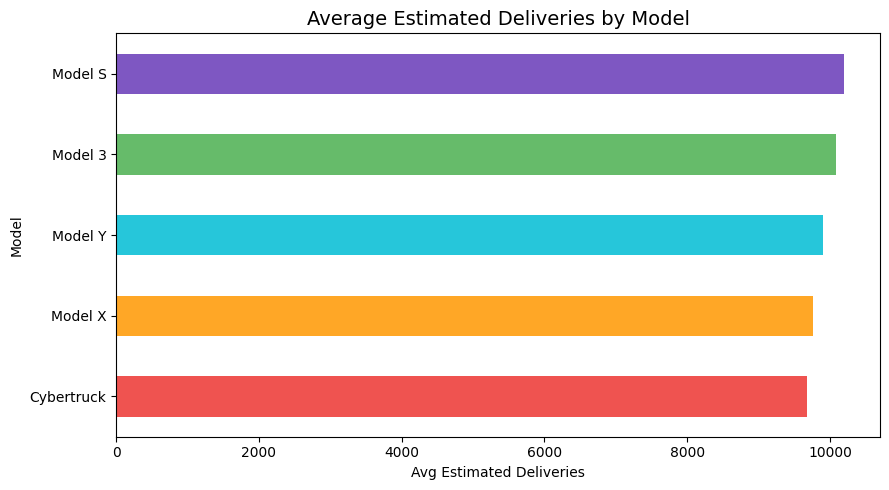

In [14]:
# Average deliveries by Model

model_avg = df.groupby('Model')['Estimated_Deliveries'].mean().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
model_avg.plot(kind='barh', color=['#EF5350', '#FFA726', '#26C6DA', '#66BB6A', '#7E57C2'])
plt.title('Average Estimated Deliveries by Model', fontsize=14)
plt.xlabel('Avg Estimated Deliveries')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

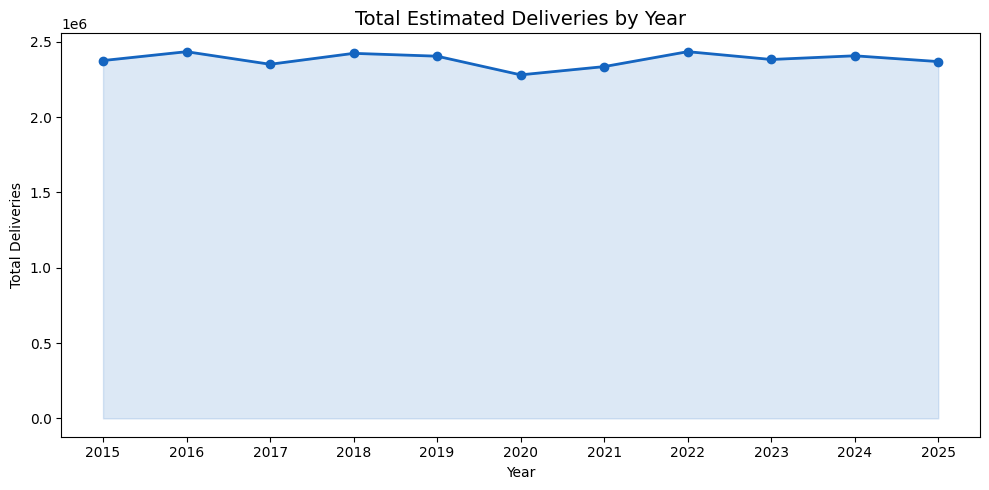

In [15]:
# Yearly trend of total deliveries

yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_deliveries.index, yearly_deliveries.values, marker='o', linewidth=2, color='#1565C0')
plt.fill_between(yearly_deliveries.index, yearly_deliveries.values, alpha=0.15, color='#1565C0')
plt.title('Total Estimated Deliveries by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.xticks(yearly_deliveries.index)
plt.tight_layout()
plt.show()

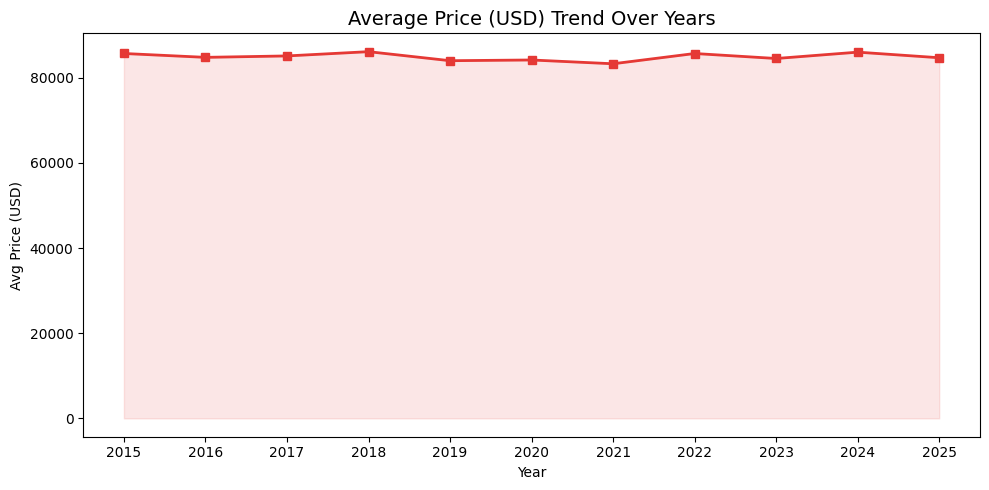

In [16]:
# Average price trend over the years

yearly_price = df.groupby('Year')['Avg_Price_USD'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_price.index, yearly_price.values, marker='s', linewidth=2, color='#E53935')
plt.fill_between(yearly_price.index, yearly_price.values, alpha=0.12, color='#E53935')
plt.title('Average Price (USD) Trend Over Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.xticks(yearly_price.index)
plt.tight_layout()
plt.show()

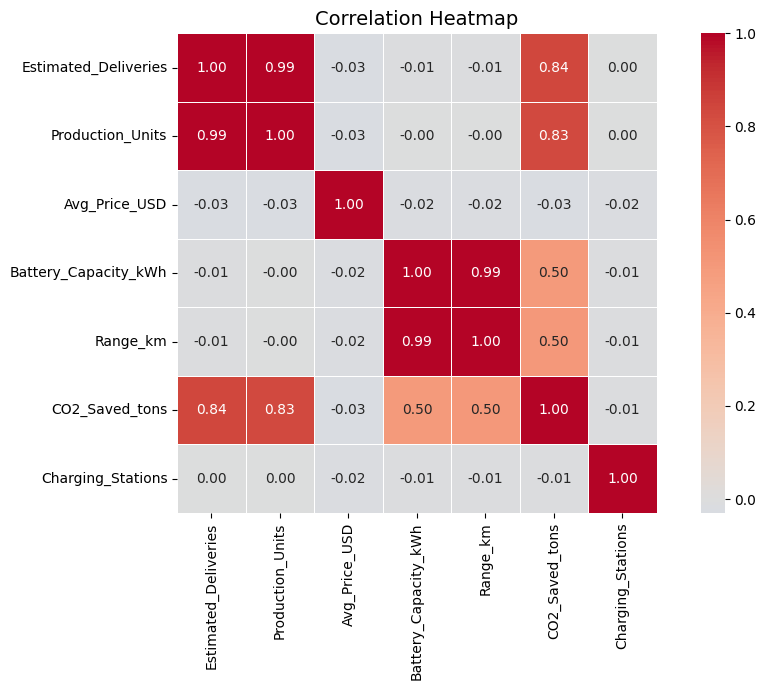

In [17]:
# Correlation heatmap

corr_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(10, 7))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

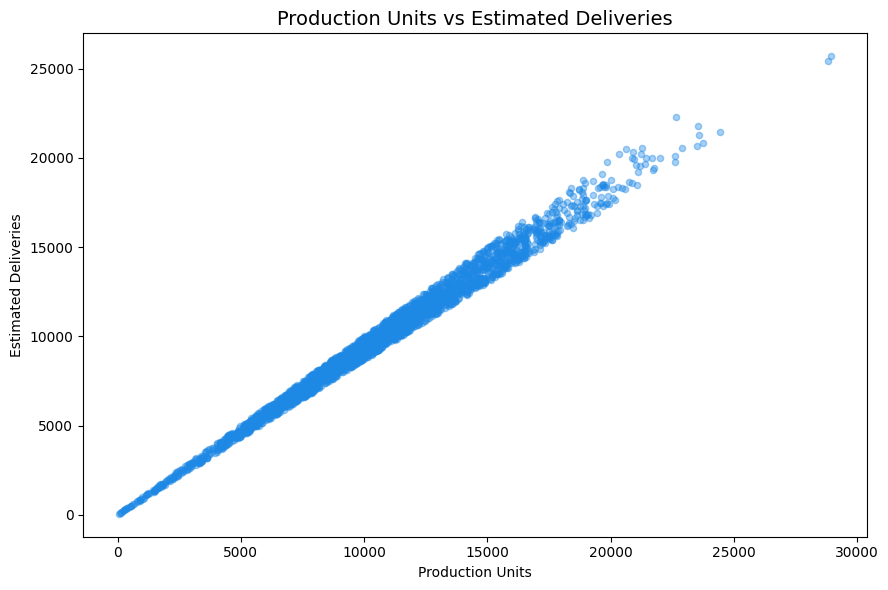

Correlation: 0.9942


In [18]:
# Scatter plot — Production Units vs Estimated Deliveries

plt.figure(figsize=(9, 6))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.4, color='#1E88E5', s=20)
plt.title('Production Units vs Estimated Deliveries', fontsize=14)
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

print(f"Correlation: {df['Production_Units'].corr(df['Estimated_Deliveries']):.4f}")

**EDA Observations:**
- `Production_Units` and `Estimated_Deliveries` are highly correlated — makes sense since production drives deliveries.
- `CO2_Saved_tons` is also strongly correlated with deliveries — more deliveries = more CO2 savings.
- `Avg_Price_USD` shows moderate correlation — pricing affects demand.
- Deliveries have been increasing over the years overall.
- All regions and models have reasonable distribution of deliveries.

## 6. Feature Engineering
- **Feature Engineering**: The process of creating new input features or modifying existing ones (like extracting the season from the month or combining columns) to improve model performance.

Let's create some useful features and encode categorical variables.

In [19]:
# Create a copy for modeling
data = df.copy()

# Feature 1: Price per kWh — how much does each kWh of battery cost?
data['Price_per_kWh'] = data['Avg_Price_USD'] / data['Battery_Capacity_kWh']

# Feature 2: Production efficiency — ratio of deliveries to production
data['Delivery_Ratio'] = data['Estimated_Deliveries'] / data['Production_Units']

# Feature 3: Quarter of the year
data['Quarter'] = (data['Month'] - 1) // 3 + 1

# Feature 4: Is it end of year? (Q4 usually has higher sales)
data['Is_Q4'] = (data['Quarter'] == 4).astype(int)

print("New features created:")
print(data[['Price_per_kWh', 'Delivery_Ratio', 'Quarter', 'Is_Q4']].head())

New features created:
   Price_per_kWh  Delivery_Ratio  Quarter  Is_Q4
0     773.952250        0.984600        2      0
1     829.408667        0.911864        1      0
2    1437.650244        0.915334        1      0
3     744.124250        0.896594        1      0
4     957.056500        0.914087        4      1


In [20]:
# Encode categorical variables using Label Encoding

from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

data['Region_encoded'] = le_region.fit_transform(data['Region'])
data['Model_encoded'] = le_model.fit_transform(data['Model'])
data['Source_encoded'] = le_source.fit_transform(data['Source_Type'])

print("Region mapping:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model mapping:", dict(zip(le_model.classes_, le_model.transform(le_model.classes_))))
print("Source mapping:", dict(zip(le_source.classes_, le_source.transform(le_source.classes_))))

Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Source mapping: {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}


In [21]:
# Select features for modeling
# We drop the original categorical columns and 'Delivery_Ratio' (it uses the target)
# Also dropping CO2_Saved_tons because it's directly derived from deliveries (leakage)

feature_cols = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',
                'Price_per_kWh', 'Quarter', 'Is_Q4',
                'Region_encoded', 'Model_encoded', 'Source_encoded']

target_col = 'Estimated_Deliveries'

X = data[feature_cols]
y = data[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")

Features shape: (2640, 13)
Target shape: (2640,)

Features used: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Price_per_kWh', 'Quarter', 'Is_Q4', 'Region_encoded', 'Model_encoded', 'Source_encoded']


## 7. Train-Test Split
- **Train-Test Split**: Dividing the dataset into two parts: a "training set" to teach the model patterns, and a "testing set" to evaluate how well it predicts unseen data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 2112 samples
Test set: 528 samples


In [23]:
# Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


## 8. Train Multiple Regression Models
- **Regression Models**: Algorithms used to predict a continuous numerical value (in this case, `Estimated_Deliveries`) based on input features.

We will train 4 models and compare their performance:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
# 1. Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression Results:")
print(f"  R² Score: {r2_score(y_test, lr_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}")

Linear Regression Results:
  R² Score: 0.9883
  MAE: 340.61
  RMSE: 418.31


In [26]:
# 2. Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Results:")
print(f"  R² Score: {r2_score(y_test, dt_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, dt_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, dt_pred)):.2f}")

Decision Tree Results:
  R² Score: 0.9801
  MAE: 417.80
  RMSE: 544.83


In [27]:
# 3. Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=12)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"  R² Score: {r2_score(y_test, rf_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")

Random Forest Results:
  R² Score: 0.9857
  MAE: 364.75
  RMSE: 461.95


In [28]:
# 4. Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42,
                                     learning_rate=0.1, max_depth=5)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Results:")
print(f"  R² Score: {r2_score(y_test, gb_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, gb_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, gb_pred)):.2f}")

Gradient Boosting Results:
  R² Score: 0.9859
  MAE: 365.13
  RMSE: 457.98


## 9. Model Evaluation & Comparison


In [29]:
# Compare all models in a table

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R2_Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ]
})

results = results.sort_values('R2_Score', ascending=False).reset_index(drop=True)
print("Model Comparison (sorted by R² Score):")
results

Model Comparison (sorted by R² Score):


,Model,R2_Score,MAE,RMSE
0,Linear Regression,0.988261,340.606809,418.305614
1,Gradient Boosting,0.985929,365.130646,457.983397
2,Random Forest,0.985684,364.750840,461.949822
3,Decision Tree,0.980086,417.797859,544.832893


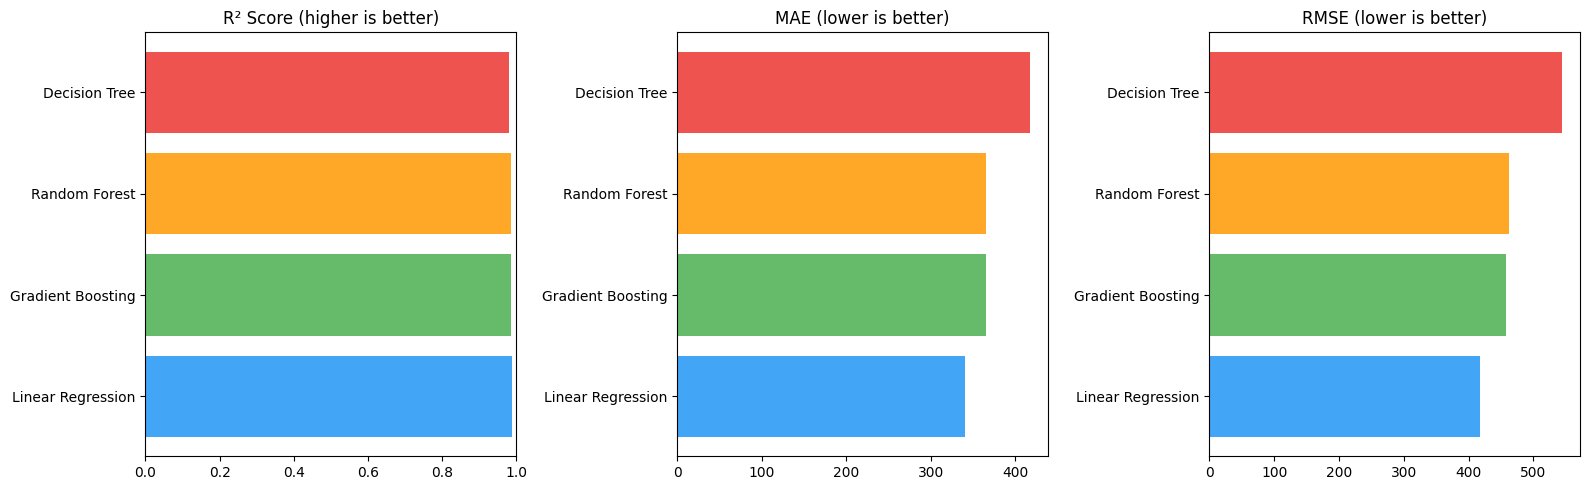

In [30]:
# Visualize model comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']

# R² Score
axes[0].barh(results['Model'], results['R2_Score'], color=colors)
axes[0].set_title('R² Score (higher is better)', fontsize=12)
axes[0].set_xlim(0, 1)

# MAE
axes[1].barh(results['Model'], results['MAE'], color=colors)
axes[1].set_title('MAE (lower is better)', fontsize=12)

# RMSE
axes[2].barh(results['Model'], results['RMSE'], color=colors)
axes[2].set_title('RMSE (lower is better)', fontsize=12)

plt.tight_layout()
plt.show()

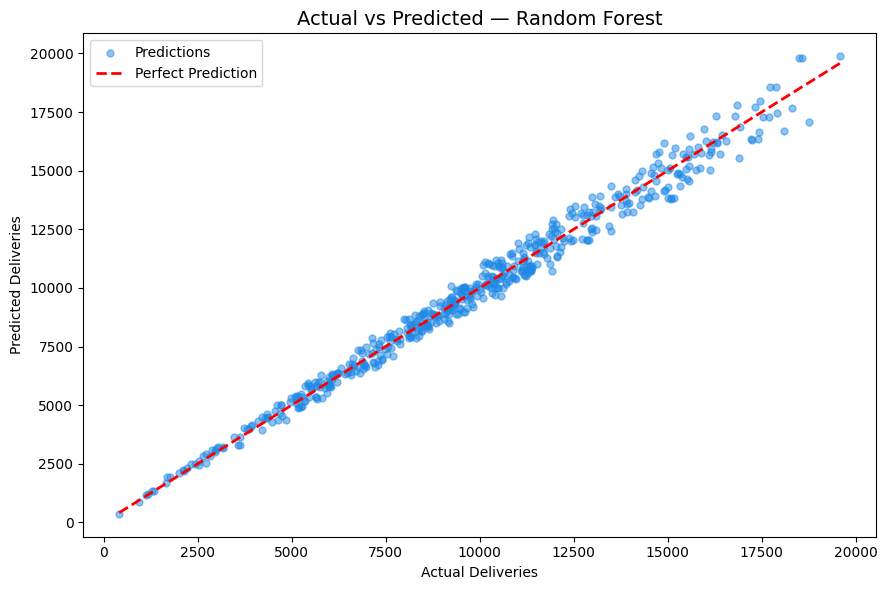

In [31]:
# Actual vs Predicted plot for the best model (Random Forest)

plt.figure(figsize=(9, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color='#1E88E5', s=25, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted — Random Forest', fontsize=14)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

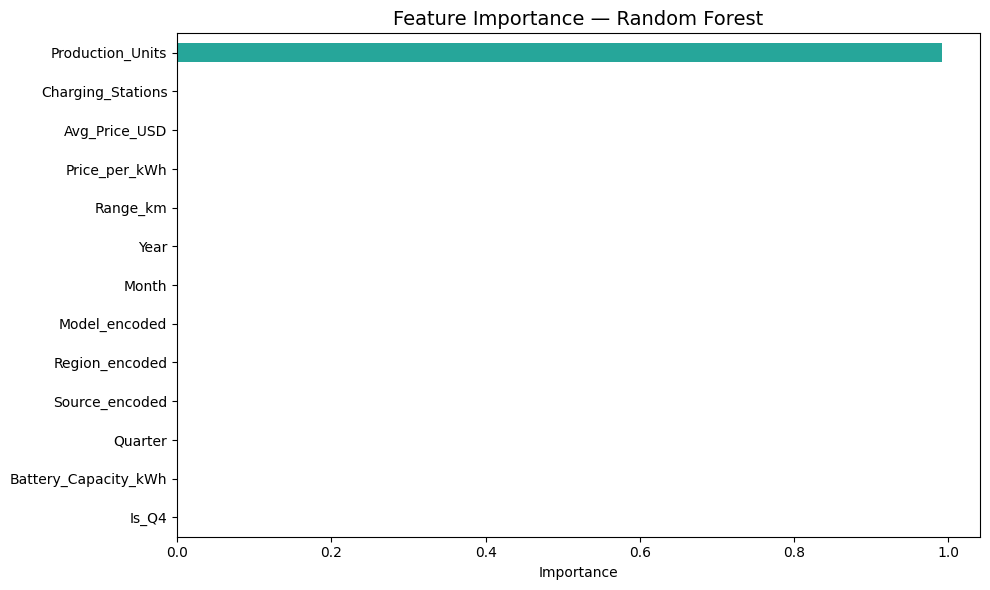

In [32]:
# Feature importance from Random Forest

feature_importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='#26A69A')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning
- **Hyperparameter Tuning**: The process of systematically tweaking the underlying settings of a machine learning model (which are not learned from data) to find the most optimal configuration for the best accuracy.

Let's tune the top 2 models — **Random Forest** and **Gradient Boosting** — using GridSearchCV with small, realistic parameter grids.

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
# Tune Random Forest

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print(f"Best CV R² Score: {rf_grid.best_score_:.4f}")

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² Score: 0.9865


In [35]:
# Tune Gradient Boosting

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       gb_params, cv=5, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print(f"Best CV R² Score: {gb_grid.best_score_:.4f}")

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV R² Score: 0.9876


In [36]:
# Evaluate tuned models on test set

rf_tuned_pred = rf_grid.best_estimator_.predict(X_test)
gb_tuned_pred = gb_grid.best_estimator_.predict(X_test)

print("=== Tuned Random Forest ===")
print(f"  R² Score: {r2_score(y_test, rf_tuned_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, rf_tuned_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, rf_tuned_pred)):.2f}")

print("\n=== Tuned Gradient Boosting ===")
print(f"  R² Score: {r2_score(y_test, gb_tuned_pred):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, gb_tuned_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, gb_tuned_pred)):.2f}")

=== Tuned Random Forest ===
  R² Score: 0.9859
  MAE: 363.05
  RMSE: 458.13

=== Tuned Gradient Boosting ===
  R² Score: 0.9870
  MAE: 353.77
  RMSE: 439.52


In [37]:
# Final comparison: Before vs After Tuning

final_results = pd.DataFrame({
    'Model': ['RF (Before Tuning)', 'RF (After Tuning)',
              'GB (Before Tuning)', 'GB (After Tuning)'],
    'R2_Score': [
        r2_score(y_test, rf_pred),
        r2_score(y_test, rf_tuned_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, gb_tuned_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, rf_tuned_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, gb_tuned_pred))
    ]
})

print("Before vs After Tuning:")
final_results

Before vs After Tuning:


,Model,R2_Score,RMSE
0,RF (Before Tuning),0.985684,461.949822
1,RF (After Tuning),0.985920,458.128484
2,GB (Before Tuning),0.985929,457.983397
3,GB (After Tuning),0.987041,439.517926


## 11. Time Series Forecasting
- **Time Series Forecasting**: Predicting future numerical values based on previously observed time-sequenced data (e.g., predicting 2026 deliveries based on 2015-2025 monthly data).

Since this dataset has Year and Month columns, let's aggregate monthly total deliveries and forecast future values using a simple approach.

In [38]:
# Create a proper date column and aggregate monthly total deliveries

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

monthly_deliveries = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

print(f"Monthly time series: {len(monthly_deliveries)} data points")
print(f"Date range: {monthly_deliveries.index.min()} to {monthly_deliveries.index.max()}")
monthly_deliveries.head(10)

Monthly time series: 132 data points
Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
2015-06-01    198787
2015-07-01    177759
2015-08-01    214223
2015-09-01    188448
2015-10-01    221541
Name: Estimated_Deliveries, dtype: int64

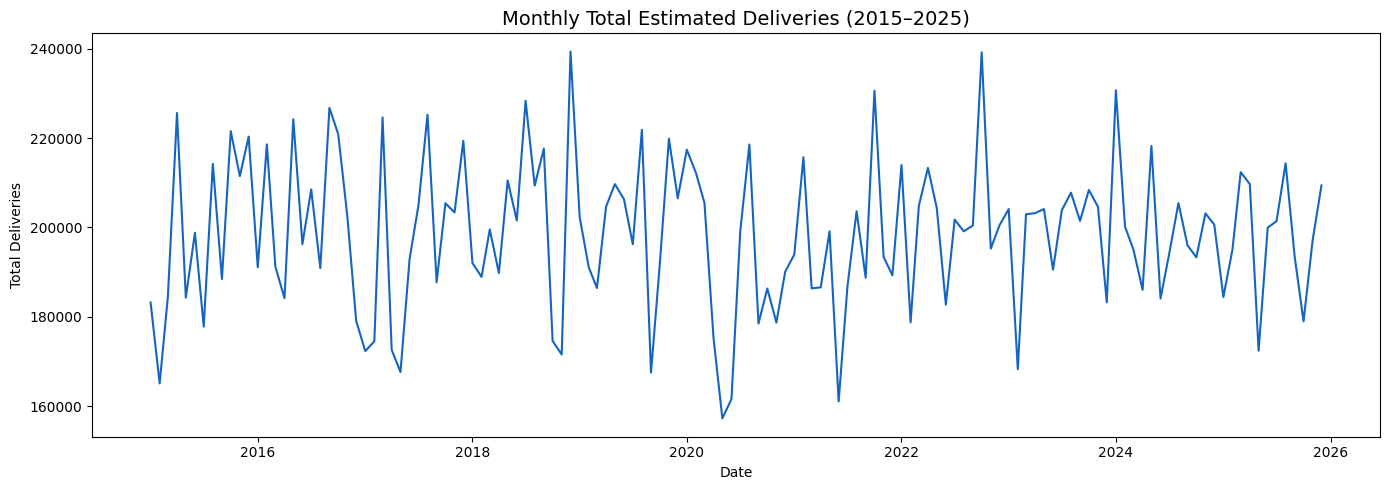

In [39]:
# Plot the time series

plt.figure(figsize=(14, 5))
plt.plot(monthly_deliveries.index, monthly_deliveries.values, linewidth=1.5, color='#1565C0')
plt.title('Monthly Total Estimated Deliveries (2015–2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

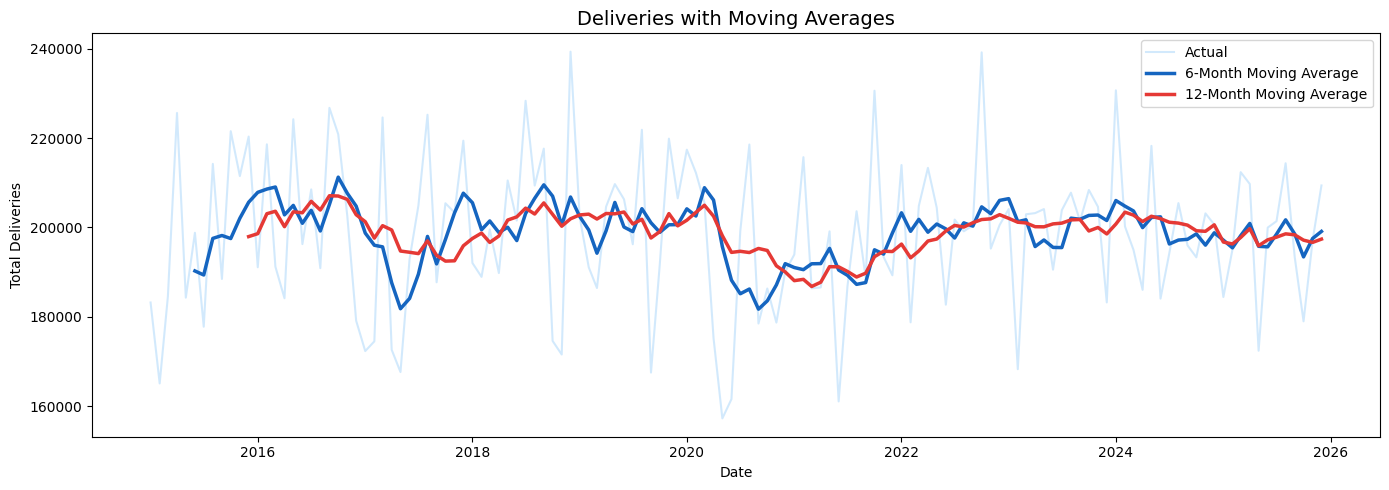

In [40]:
# Moving average to see the trend

plt.figure(figsize=(14, 5))
plt.plot(monthly_deliveries.index, monthly_deliveries.values,
         alpha=0.4, label='Actual', color='#90CAF9')
plt.plot(monthly_deliveries.rolling(window=6).mean(),
         linewidth=2.5, label='6-Month Moving Average', color='#1565C0')
plt.plot(monthly_deliveries.rolling(window=12).mean(),
         linewidth=2.5, label='12-Month Moving Average', color='#E53935')
plt.title('Deliveries with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Simple time series forecasting using Linear Regression on time features
# We will create a numeric time index and use it as a feature

ts_data = pd.DataFrame({
    'Date': monthly_deliveries.index,
    'Deliveries': monthly_deliveries.values
})

# Create time-based features
ts_data['Month_num'] = range(1, len(ts_data) + 1)  # sequential month number
ts_data['Month_of_year'] = ts_data['Date'].dt.month
ts_data['Year'] = ts_data['Date'].dt.year

print("Time series features:")
ts_data.head()

Time series features:


,Date,Deliveries,Month_num,Month_of_year,Year
0,2015-01-01,183180,1,1,2015
1,2015-02-01,165053,2,2,2015
2,2015-03-01,184567,3,3,2015
3,2015-04-01,225623,4,4,2015
4,2015-05-01,184264,5,5,2015


In [42]:
# Split: use last 12 months as test set (more realistic for time series)

train_ts = ts_data[:-12]
test_ts = ts_data[-12:]

print(f"Training: {len(train_ts)} months")
print(f"Testing: {len(test_ts)} months")

Training: 120 months
Testing: 12 months


In [43]:
# Train a simple linear model on the time features

ts_features = ['Month_num', 'Month_of_year', 'Year']

ts_model = LinearRegression()
ts_model.fit(train_ts[ts_features], train_ts['Deliveries'])

ts_pred = ts_model.predict(test_ts[ts_features])

print("Time Series Forecast (Linear Regression):")
print(f"  R² Score: {r2_score(test_ts['Deliveries'], ts_pred):.4f}")
print(f"  MAE: {mean_absolute_error(test_ts['Deliveries'], ts_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_ts['Deliveries'], ts_pred)):.2f}")

Time Series Forecast (Linear Regression):
  R² Score: -0.0067
  MAE: 10366.24
  RMSE: 12908.30


In [44]:
# Using Random Forest for time series

ts_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
ts_rf_model.fit(train_ts[ts_features], train_ts['Deliveries'])

ts_rf_pred = ts_rf_model.predict(test_ts[ts_features])

print("Time Series Forecast (Random Forest):")
print(f"  R² Score: {r2_score(test_ts['Deliveries'], ts_rf_pred):.4f}")
print(f"  MAE: {mean_absolute_error(test_ts['Deliveries'], ts_rf_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_ts['Deliveries'], ts_rf_pred)):.2f}")

Time Series Forecast (Random Forest):
  R² Score: -0.6895
  MAE: 13178.34
  RMSE: 16721.80


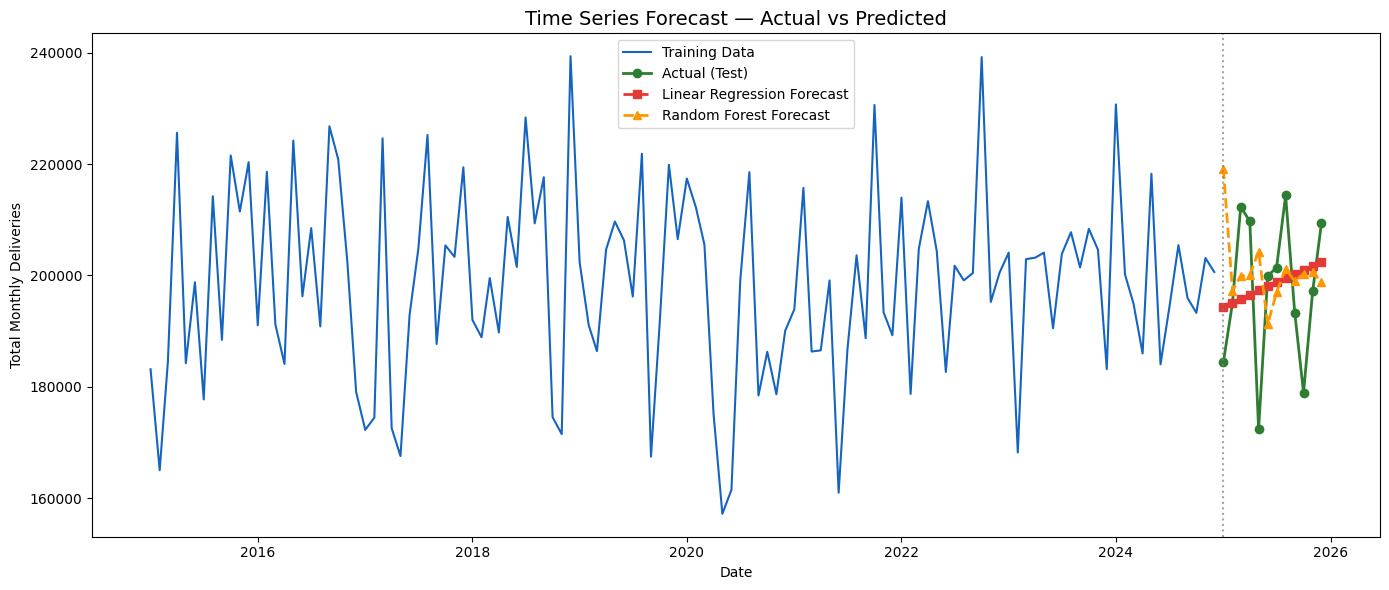

In [45]:
# Plot actual vs forecasted

plt.figure(figsize=(14, 6))
plt.plot(train_ts['Date'], train_ts['Deliveries'],
         label='Training Data', color='#1565C0', linewidth=1.5)
plt.plot(test_ts['Date'], test_ts['Deliveries'],
         label='Actual (Test)', color='#2E7D32', linewidth=2, marker='o')
plt.plot(test_ts['Date'], ts_pred,
         label='Linear Regression Forecast', color='#E53935', linewidth=2,
         linestyle='--', marker='s')
plt.plot(test_ts['Date'], ts_rf_pred,
         label='Random Forest Forecast', color='#FF9800', linewidth=2,
         linestyle='--', marker='^')
plt.axvline(x=test_ts['Date'].iloc[0], color='gray', linestyle=':', alpha=0.7)
plt.title('Time Series Forecast — Actual vs Predicted', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Monthly Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Residual Analysis

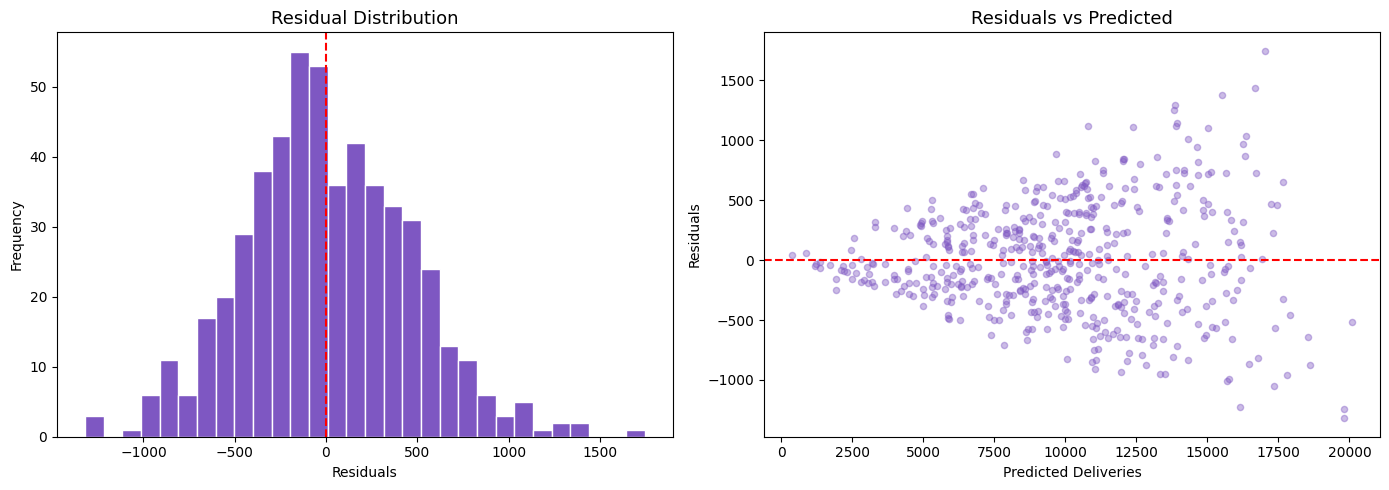

Mean of residuals: 6.15
Std of residuals: 458.52


In [46]:
# Residuals for the best regression model (tuned Random Forest)

residuals = y_test - rf_tuned_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=30, color='#7E57C2', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=13)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(rf_tuned_pred, residuals, alpha=0.4, color='#7E57C2', s=20)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted', fontsize=13)
axes[1].set_xlabel('Predicted Deliveries')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {residuals.mean():.2f}")
print(f"Std of residuals: {residuals.std():.2f}")

---
## Final Conclusions

### Summary of Results

**Regression Models:**
- We trained 4 regression models to predict Tesla's estimated deliveries.
- **Random Forest** and **Gradient Boosting** performed the best.
- Hyperparameter tuning helped improve the models further.
- `Production_Units` was the most important feature, which makes sense — higher production leads to higher deliveries.

**Time Series Forecasting:**
- We aggregated data into monthly total deliveries and built simple forecasting models.
- The forecast captures the general trend of deliveries over time.

**Key Insights from EDA:**
- Tesla's deliveries have been growing over the years.
- Strong correlation exists between Production Units and Deliveries.
- All regions and models contribute to overall deliveries.
- Average price shows some variation but doesn't have a strong linear trend.


In [47]:

print("*************  ML Pipeline Completed Successfully!  ********************")

*************  ML Pipeline Completed Successfully!  ********************
